# SAMI · Notebook 3 — What the text says

**Mandate (Act 3, semantic).** This notebook builds the pipeline's categorization. The
platform's own `Chat_summary` labelling was retired (2026-08-03): it was the bot
summarising itself, and its coverage degraded as the v2 platform moved to free prose. The
discovered clusters — archetypes — replace it, named in users' own words and held to a
stability bar before they're trusted. The notebook produces exactly three things:
**archetypes**, **candidate emergent needs the archetypes don't separate out**, and a
**tone signal whose reliability is measured before it is used**. Every figure carries an
assertion-evidence title, its metric, its n and the window; every number traces to the P10
reconciliation table reproduced top and bottom. Modules compute, this notebook consumes.

> **Two honesty gates govern this notebook, and both are enforced in code, not prose.**
>
> 1. **Clustering must be stable to be called an archetype.** k is chosen from a scan
>    plus a 50-resample bootstrap, never by fiat.
> 2. **The tone model must be validated before any percentage is quoted.** A blind
>    sample sets Cohen's κ; below κ = 0.7 every sentiment percentage in this notebook is
>    suppressed and findings are reported as ordering only.


In [1]:
import math
import sys, pathlib
# Locate src/ by walking up from the working directory, so `sami` imports
# whether the kernel starts in notebooks/ (JupyterLab) or at the repo root
# (VS Code) — a bare "../src" only works in the first case.
_cwd = pathlib.Path.cwd()
_src = next((p / "src" for p in (_cwd, *_cwd.parents) if (p / "src" / "sami").is_dir()), None)
if _src is None:
    raise RuntimeError(f"Could not find src/sami/ above {_cwd}. "
                       "Run this notebook from inside the repository.")
sys.path.insert(0, str(_src))
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sami import load_sami, nlp, clusters, validation, metrics, taxonomy, theme, qa, export

RANDOM_STATE = 0
SD = load_sami()
WINDOW = f"{SD.run_meta['ts_min'][:10]} → {SD.run_meta['ts_max'][:10]}"
SRC = "source: MMC bot responses + MEAL survey"


In [2]:
print("Source:", SD.run_meta["responses_file"], "|", SD.run_meta["responses_rows"], "rows |", WINDOW)
dev = nlp.device_report()
print(f"Compute: {dev['device']} ({dev['gpu']}) · torch {dev['torch']}")
print(f"Embeddings : {dev['embed_model']} @ {dev['embed_revision'][:12]}")
print(f"Sentiment  : {dev['sentiment_model']} @ {dev['sentiment_revision'][:12]}")
recon_top = SD.reconciliation.copy()
recon_top

Source: Users_Group_Title_2807.xlsx | 1460 rows | 2026-03-25 → 2026-07-28


Compute: cuda (NVIDIA GeForce RTX 3050 Ti Laptop GPU) · torch 2.11.0+cu128
Embeddings : intfloat/multilingual-e5-large @ 3d7cfbdacd47
Sentiment  : cardiffnlp/twitter-xlm-roberta-base-sentiment @ f2f1202b1bde


,metric,value
0,users,1392
1,records,1459
2,messages,4663
3,users_with_text,1198
4,meal_responses,115
5,meal_response_rate_pct,8.3
6,repeat_askers_pct,10.6
7,negative_tone_pct,pending


## 1 · Representation — what exactly is being modelled

One document per user: every message that user sent, concatenated. User-level (not
message-level) is the right grain for archetypes, because the unit we want to name is a
*person with a need*, not an isolated sentence. Embeddings are multilingual e5-large at a
pinned revision, L2-normalized, so cosine distance is the geometry throughout.

In [3]:
docs = nlp.user_documents(SD.messages)
X = nlp.embed_documents(docs["doc"].tolist())
print(f"{len(docs):,} user documents  ({docs['n_msgs'].sum():,} non-empty messages of "
      f"{len(SD.messages):,} in the spine)")
print(f"embedding matrix: {X.shape[0]:,} x {X.shape[1]} · unit-norm: {np.allclose(np.linalg.norm(X,axis=1),1,atol=1e-4)}")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

1,198 user documents  (4,663 non-empty messages of 4,663 in the spine)
embedding matrix: 1,198 x 1024 · unit-norm: True


## 2 · Archetypes — how many groups, and are they real?

The scan below is the whole argument for how k was chosen, so it runs before any
archetype is named. Two metrics are read together:

- **Silhouette is flat and near zero** across k = 4…12 — a spread of well under 0.02.
  It cannot discriminate, so it is not the criterion; on a flat curve, argmax is noise.
- **Bootstrap stability is the criterion k is chosen on:** the largest k whose mean
  pairwise ARI clears the 0.6 bar by at least one standard deviation.

On the previous corpus these disagreed sharply — argmax silhouette wanted k = 8, which
failed the stability bar outright — and that disagreement was the argument for ignoring
silhouette. **On the v2 corpus they agree on the chosen k (printed below).** That
agreement is reassuring, but it does not promote silhouette: the curve is still flat, so
it still carries no information. The decision rule is unchanged, and it is the rule, not
the coincidence, that is load-bearing.


In [4]:
scan = clusters.k_scan(X, k_range=range(4, 13), random_state=RANDOM_STATE)
stab_curve = clusters.stability_curve(X, k_range=range(3, 13), n_boot=30, random_state=RANDOM_STATE)
K = clusters.choose_k(scan, stability_by_k=stab_curve)

print(f"silhouette flat (spread {scan['silhouette'].max()-scan['silhouette'].min():.4f})? "
      f"{clusters.silhouette_is_flat(scan)}")
# State what the two criteria actually did; do not assert a fixed verdict. On the
# v1 corpus argmax-silhouette picked k=8, which failed the stability bar, and that
# disagreement was the argument. On the v2 corpus the two agree — still worth
# printing, because the agreement is evidence, but it must not read as a failure.
_k_sil = clusters.choose_k(scan)
_sil_stab = stab_curve[_k_sil]["mean_ari"]
_verdict = ("clears the bar too — the two criteria agree here"
            if stab_curve[_k_sil]["stable"] else "fails the stability bar")
print(f"argmax-silhouette k would be {_k_sil} (stability {_sil_stab:.3f} — {_verdict})")
print(f"chosen k = {K}")

stab = clusters.stability_ari(X, K, n_boot=50, random_state=RANDOM_STATE)
STABLE = stab["stable"]
print(f"k={K} stability over 50 resamples: mean pairwise ARI = {stab['mean_ari']:.3f} "
      f"± {stab['std_ari']:.3f}  →  {'STABLE' if STABLE else 'SOFT STRUCTURE'}")

labels = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE).fit(X).labels_
lab = pd.Series(labels, index=docs["user_id"].values, name="archetype")
terms = clusters.ctfidf_terms(docs["doc"].tolist(), labels, top_n=12)

# Cluster names resolve through a marker-keyed registry (taxonomy.CLUSTER_NAMES),
# never a cluster-id-keyed dict: ids are an artefact of one clustering run and are
# not stable across a data refresh. A cluster whose marker no longer appears in its
# own top terms is auto-named and flagged provisional rather than blocking the run.
RESOLVED = taxonomy.resolve_cluster_names(terms)
NAMES = {c: RESOLVED[c]["name"] for c in sorted(terms)}
N_PROVISIONAL = sum(1 for c in NAMES if RESOLVED[c]["provisional"])
if N_PROVISIONAL:
    print(f"NOTE: {N_PROVISIONAL} of {len(NAMES)} cluster name(s) are provisional "
          "— their marker term wasn't in the rendered top terms. Read the c-TF-IDF "
          "terms in Figure 2 and add an entry to taxonomy.CLUSTER_NAMES.")

# theme.CLUSTER_IDENTITY is validated to theme.K_SOFT_CAP colours. k is chosen by the
# stability rule above and may exceed it -- if it does, colour alone can no longer
# carry identity and every figure below must direct-label its marks.
if len(NAMES) > theme.K_SOFT_CAP:
    print(f"NOTE: {len(NAMES)} clusters exceeds the {theme.K_SOFT_CAP}-colour "
          "validated palette. Figures below direct-label every mark; do not "
          "read identity from colour.")

# Colour by SIZE RANK, not cluster id -- ids are an artefact of this run; "the
# biggest cluster is brand teal" is the stable statement (mirrors
# export.build_dim_cluster).
_size_order = (pd.Series(labels).value_counts().rename_axis("cluster_id")
               .reset_index(name="n")
               .sort_values(["n", "cluster_id"], ascending=[False, True], kind="stable")
               ["cluster_id"].tolist())
_rank = {cid: i for i, cid in enumerate(_size_order)}
_palette = theme.cluster_colors(len(_size_order))
ACOLOR = {c: _palette[_rank[c]] for c in NAMES}

print("archetypes:", ", ".join(f"{c}={NAMES[c]}" for c in sorted(NAMES)))


silhouette flat (spread 0.0146)? True
argmax-silhouette k would be 6 (stability 0.858 — clears the bar too — the two criteria agree here)
chosen k = 6


k=6 stability over 50 resamples: mean pairwise ARI = 0.836 ± 0.082  →  STABLE


archetypes: 0=Building a livelihood, 1=Stuck mid-procedure, 2=Nationality and family papers, 3=Permits, visas and travel, 4=Urgent humanitarian needs, 5=Settling in


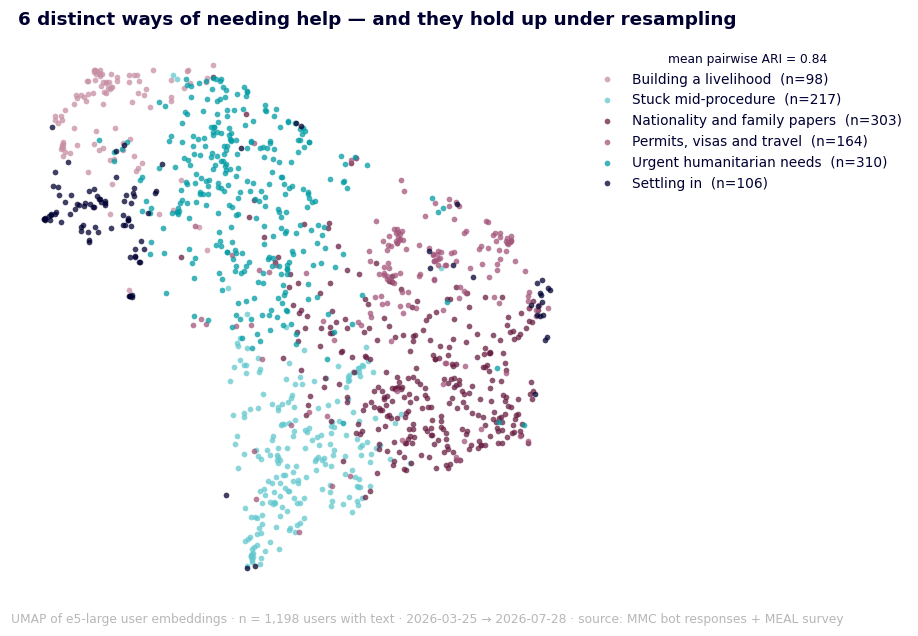

In [5]:
# --- Figure 1: the archetype map ---
XY = clusters.project_2d(X, method="umap", random_state=RANDOM_STATE)
fig, ax = plt.subplots(figsize=(8.4, 5.6))
for c in sorted(terms):
    m = labels == c
    ax.scatter(XY[m, 0], XY[m, 1], s=14, alpha=0.75, color=ACOLOR[c],
               label=f"{NAMES[c]}  (n={int(m.sum())})", linewidths=0)
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values():
    s.set_visible(False)
verdict = "hold up under resampling" if STABLE else "are soft structure"
ax.set_title(f"{K} distinct ways of needing help — and they {verdict}")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=9, frameon=False,
          title=f"mean pairwise ARI = {stab['mean_ari']:.2f}", title_fontsize=8)
fig.text(0.01, -0.02, f"UMAP of e5-large user embeddings · n = {len(docs):,} users with text · "
                      f"{WINDOW} · {SRC}", fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()

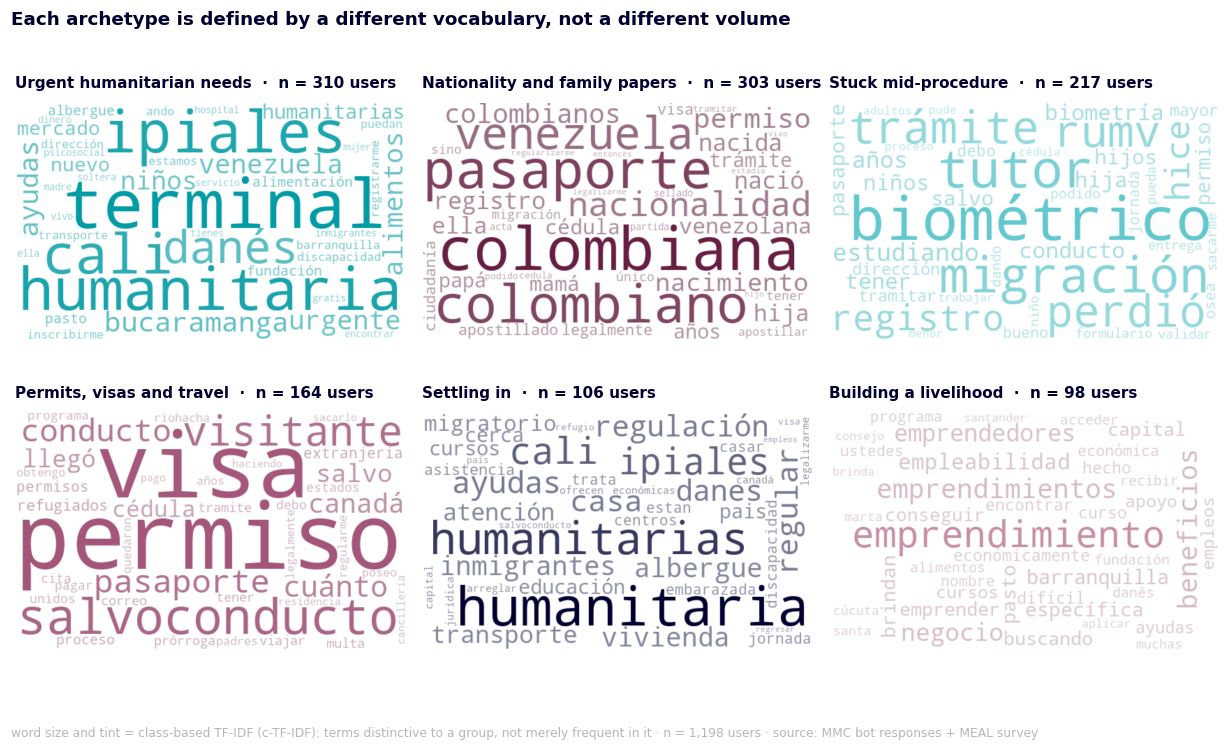

In [6]:
# --- Figure 2: what makes each archetype distinctive ---
# Word size and tint both carry the same c-TF-IDF weight, so colour is redundant
# with size rather than a second variable. Raw frequency is deliberately NOT used:
# it would render the same corpus-wide vocabulary in every cloud, and it would
# bypass the distinct-user floor in ctfidf_terms that keeps personal names out of
# a rendered term list.
cloud_terms = clusters.ctfidf_terms(docs["doc"].tolist(), labels, top_n=40)
_all_terms = sorted({t for s in cloud_terms.values() for t in s.index})
assert qa.pii_scan(pd.DataFrame({"term": _all_terms})) == [], "PII in a rendered term"

order = sorted(terms, key=lambda c: -int((labels == c).sum()))
# Grid sized to K so the figure survives a k change; any spare panel is hidden.
_ncol = 3 if len(order) > 4 else 2
_nrow = math.ceil(len(order) / _ncol)
fig, axes = plt.subplots(_nrow, _ncol, figsize=(3.75 * _ncol, 3.3 * _nrow))
axes = np.atleast_1d(axes).ravel()
for ax in axes[len(order):]:
    ax.axis("off")
for ax, c in zip(axes, order):
    ax.imshow(theme.wordcloud_image(cloud_terms[c], ACOLOR[c]), interpolation="bilinear")
    ax.set_title(f"{NAMES[c]}  ·  n = {int((labels==c).sum())} users", fontsize=10)
    ax.axis("off")
fig.suptitle("Each archetype is defined by a different vocabulary, not a different volume",
             x=0.01, ha="left", fontsize=12, weight="semibold")
fig.text(0.01, -0.02, "word size and tint = class-based TF-IDF (c-TF-IDF): terms distinctive to a "
                      f"group, not merely frequent in it · n = {len(docs):,} users · {SRC}",
         fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()


In [7]:
# --- Archetype table: size, profile, and one verbatim voice each ---
prof = clusters.archetype_profiles(lab, SD.responses, SD.messages, terms=terms)
msgs_lab = SD.messages.assign(archetype=SD.messages["user_id"].map(lab)).dropna(subset=["archetype"])
msgs_lab["archetype"] = msgs_lab["archetype"].astype(int)

def pick_quote(cid):
    # Deterministic: the first mid-length message carrying the archetype's marker term.
    marker = RESOLVED[cid]["marker"]
    g = msgs_lab[(msgs_lab.archetype == cid)
                 & msgs_lab.message.str.len().between(60, 190)
                 & msgs_lab.message.str.contains(marker, case=False, na=False)]
    g = g.sort_values(["user_id", "seq"], kind="stable")
    return g["message"].iloc[0] if len(g) else "—"

table = pd.DataFrame({
    "Archetype": [NAMES[c] + (" *" if RESOLVED[c]["provisional"] else "") for c in prof.index],
    "Users": prof["n_users"].values,
    "Messages": prof["n_messages"].values,
    "Median age": prof["median_age"].values,
    "Distinctive terms": prof["top_terms"].values,
    "In their words": [pick_quote(c) for c in prof.index],
})
assert qa.pii_scan(table[["In their words"]]) == [], "PII in a rendered quote"

_n_prov = sum(RESOLVED[c]["provisional"] for c in prof.index)
_caption = (f"* provisional name — terms not yet reviewed ({_n_prov} of {len(table)} archetypes)"
            if _n_prov else
            f"All {len(table)} archetype names are curated; none are provisional this run.")
(table.style.hide(axis="index")
      .set_properties(subset=["In their words"], **{"width": "360px"})
      .set_caption(_caption))


Archetype,Users,Messages,Median age,Distinctive terms,In their words
Urgent humanitarian needs,310,1854,33.000000,"terminal, humanitaria, ipiales, cali, danés, bucaramanga",Cual ayuda mas recurrente da el pao en Medellín terminal del norte
Nationality and family papers,303,1292,32.000000,"colombiana, pasaporte, colombiano, venezuela, nacionalidad, permiso",Y que documentos necesito para darle la nacionalidad venezolana a mi hija
Stuck mid-procedure,217,743,31.000000,"biométrico, tutor, migración, trámite, rumv, perdió",Pero luego del biométrico puedo usar el rumv para afiliación de eps
"Permits, visas and travel",164,394,33.000000,"permiso, visa, salvoconducto, visitante, pasaporte, conducto",Me dijeron que puedo hacer una visa especial de visitante ya que mi pasaporte está vigente y el último sello de entrada fué en 2023
Settling in,106,172,32.000000,"humanitaria, humanitarias, cali, ipiales, ayudas, casa",—
Building a livelihood,98,208,35.000000,"emprendimiento, emprendimientos, beneficios, negocio, emprendedores, empleabilidad",Hola me gustaría q me diera información sobre... empleo o emprendimiento.


## 2b · Subcategories — what each archetype splits into

The archetypes above answer "what kinds of people write to SAMI". They do not
answer "about what, specifically". A second clustering pass, run **inside** each
archetype, does: five of the six split, into twelve subcategories.

Two rules make this honest rather than decorative:

- **A parent only splits if the split is stable and every child clears 30
  users.** That floor is a disclosure control, not only a statistical one — a
  subcategory of eight people is a description of eight people. *Settling in*
  was eligible and did not split; it keeps one child covering the whole parent,
  so the drill-down stays total.
- **Children are described by their SIBLING-EXCLUSIVE terms.** Siblings of one
  parent share most of their vocabulary; ranking a child by its raw top terms
  would print the parent's words three times. What is shown below is what each
  child says that its siblings do not.


In [8]:
# --- Subcategories: the second clustering pass, inside each archetype ---
from sami import subclusters

sub_lab, sub_meta = subclusters.subcluster_all(
    X, lab, docs["user_id"].values, random_state=RANDOM_STATE)

# Terms are made SIBLING-EXCLUSIVE before naming: a marker on a term two
# children share would be claimed by whichever child is visited first.
sub_docs = docs.assign(sub=docs["user_id"].map(sub_lab.to_dict()))
sub_terms_raw = clusters.ctfidf_terms(sub_docs["doc"].tolist(), sub_docs["sub"].values, top_n=40)
SUB_TERMS = subclusters.exclusive_terms(sub_terms_raw)
RESOLVED_SUB = taxonomy.resolve_names(SUB_TERMS, taxonomy.SUBCLUSTER_NAMES, kind="subcluster")
SUB_NAMES = {sid: v["name"] for sid, v in RESOLVED_SUB.items()}

_split = [c for c, m in sub_meta.items() if m["is_split"]]
_aris = [sub_meta[c]["stability_ari"] for c in _split]
_n_prov_sub = sum(1 for v in RESOLVED_SUB.values() if v["provisional"])

print(f"{len(_split)} of {len(sub_meta)} archetypes split -> {len(SUB_NAMES)} subcategories")
print(f"smallest subcategory: {int(sub_lab[sub_lab >= 0].value_counts().min()):,} users "
      f"(floor is {subclusters.SUBCLUSTER_MIN_USERS})")
print(f"mean child stability (split parents only): ARI = {np.mean(_aris):.3f}  "
      f"vs the parent pass's {stab['mean_ari']:.3f}")
if _n_prov_sub:
    print(f"NOTE: {_n_prov_sub} subcategory name(s) are provisional — read the "
          "exclusive terms below and add an entry to taxonomy.SUBCLUSTER_NAMES.")
else:
    print(f"All {len(SUB_NAMES)} subcategory names are curated; none are provisional.")


5 of 6 archetypes split -> 12 subcategories
smallest subcategory: 38 users (floor is 30)
mean child stability (split parents only): ARI = 0.841  vs the parent pass's 0.836
All 12 subcategory names are curated; none are provisional.


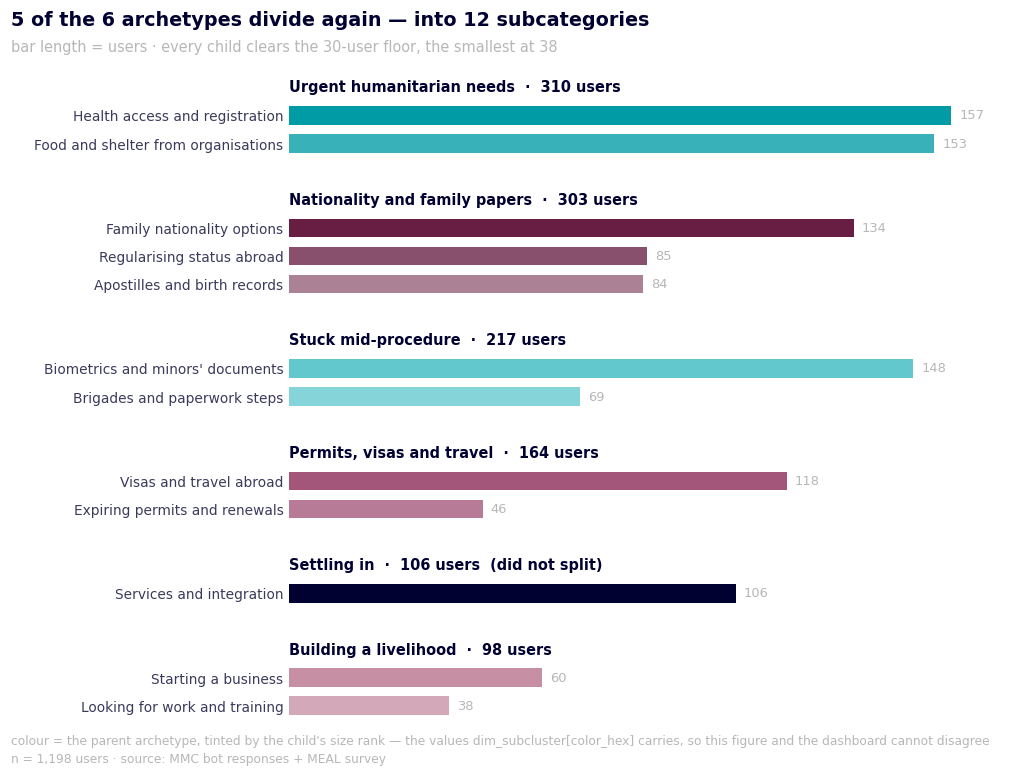

In [9]:
# --- Figure 2c: how each archetype divides ---
# A parent header and a child bar occupy DIFFERENT rows. The first version drew
# the parent name in the same right-aligned column as the child tick labels, so
# wherever a parent's mean y landed on a child row the two strings printed on top
# of each other. Giving the header its own row makes that collision structurally
# impossible instead of tuning it away.
#
# No x-axis and no threshold rule: with twelve bars the value label IS the
# reading, and a dashed line every bar clears by 8x is chrome, not information.
_sizes = sub_lab[sub_lab >= 0].value_counts()
_kids_of = {cid: sorted([s for s in _sizes.index if s // 10 == cid],
                        key=lambda s: (-_sizes[s], s))
            for cid in sorted(sub_meta)}
_total = {cid: int(sum(_sizes[s] for s in kids)) for cid, kids in _kids_of.items()}

# Parents in size order, largest first -- the same rule that assigns their
# colours, so the reading order and the palette tell the same story.
rows = []                       # ("head", cid) | ("bar", (cid, sid)) | ("gap", None)
for i, cid in enumerate(sorted(_total, key=lambda c: -_total[c])):
    if i:
        rows.append(("gap", None))
    rows.append(("head", cid))
    rows += [("bar", (cid, sid)) for sid in _kids_of[cid]]

_y = {i: len(rows) - 1 - i for i in range(len(rows))}
bars = [(_y[i], v) for i, (k, v) in enumerate(rows) if k == "bar"]
heads = [(_y[i], v) for i, (k, v) in enumerate(rows) if k == "head"]

# Height is derived from the row count, so a future run with more children grows
# the figure instead of cramming them.
ROW_IN, TITLE_IN, FOOT_IN = 0.26, 0.78, 0.46
FIG_H = ROW_IN * len(rows) + TITLE_IN + FOOT_IN
fig, ax = plt.subplots(figsize=(9.6, FIG_H))
xmax = int(_sizes.max())

# Children are tints of their PARENT's colour, by size rank: a subcategory is a
# subdivision, and an unrelated hue would make this read as twelve independent
# series rather than two levels of one. These are the same values
# dim_subcluster[color_hex] carries, so the figure and the dashboard agree.
_fill = {}
for cid, kids in _kids_of.items():
    tints = theme.subcluster_colors(ACOLOR[cid], len(kids))
    for rank, sid in enumerate(kids):
        _fill[sid] = tints[rank]

ax.barh([y for y, _ in bars], [int(_sizes[sid]) for _, (_, sid) in bars],
        color=[_fill[sid] for _, (_, sid) in bars], height=0.66)
for y, (_, sid) in bars:
    ax.text(int(_sizes[sid]) + xmax * 0.012, y, f"{int(_sizes[sid]):,}",
            va="center", fontsize=8.5, color=theme.MUTED)

ax.set_yticks([y for y, _ in bars])
ax.set_yticklabels([SUB_NAMES[sid] for _, (_, sid) in bars], fontsize=9)

for y, cid in heads:
    tag = "" if len(_kids_of[cid]) > 1 else "  (did not split)"
    ax.text(0, y, f"{NAMES[cid]}  ·  {_total[cid]:,} users{tag}",
            transform=ax.get_yaxis_transform(), ha="left", va="center",
            fontsize=9.5, weight="semibold", color=theme.INK, clip_on=False)

ax.set_xlim(0, xmax * 1.10)
ax.set_ylim(-0.7, len(rows) - 0.3)
ax.set_xticks([])
for s in ("top", "right", "left", "bottom"):
    ax.spines[s].set_visible(False)
ax.tick_params(axis="y", length=0)

fig.text(0.012, 1 - 0.26 / FIG_H,
         f"{len(_split)} of the {len(sub_meta)} archetypes divide again — into "
         f"{len(SUB_NAMES)} subcategories",
         ha="left", va="top", fontsize=12.5, weight="semibold", color=theme.INK)
fig.text(0.012, 1 - 0.52 / FIG_H,
         f"bar length = users · every child clears the {subclusters.SUBCLUSTER_MIN_USERS}-user "
         f"floor, the smallest at {int(_sizes.min())}",
         ha="left", va="top", fontsize=9.5, color=theme.MUTED)
fig.text(0.012, 0.10 / FIG_H,
         "colour = the parent archetype, tinted by the child's size rank — the values "
         "dim_subcluster[color_hex] carries, so this figure and the dashboard cannot disagree\n"
         f"n = {len(docs):,} users · {SRC}",
         ha="left", va="bottom", fontsize=8, color=theme.MUTED, linespacing=1.5)

fig.subplots_adjust(top=1 - TITLE_IN / FIG_H, bottom=FOOT_IN / FIG_H,
                    left=0.275, right=0.965)
plt.show()


In [10]:
# --- Subcategory table: what each child says that its siblings do not ---
_msg_sub = SD.messages["user_id"].map(sub_lab.to_dict())
_n_msgs = _msg_sub.value_counts()

rows = []
for cid in sorted(sub_meta):
    kids = sorted([s for s in _sizes.index if s // 10 == cid], key=lambda s: (-_sizes[s], s))
    for sid in kids:
        rows.append({
            "Archetype": NAMES[cid],
            "Subcategory": SUB_NAMES[sid] + (" *" if RESOLVED_SUB[sid]["provisional"] else ""),
            "Users": int(_sizes[sid]),
            "Messages": int(_n_msgs.get(sid, 0)),
            "Exclusive terms": ", ".join(list(SUB_TERMS[sid].index[:6])),
            "Split?": "yes" if sub_meta[cid]["is_split"] else "no (parent kept whole)",
            "Child ARI": (f"{sub_meta[cid]['stability_ari']:.3f}"
                          if sub_meta[cid]["is_split"] else "—"),
        })
sub_table = pd.DataFrame(rows)
assert qa.pii_scan(sub_table[["Exclusive terms"]]) == [], "PII in a rendered term"

(sub_table.style.hide(axis="index")
    .set_caption("Child ARI is the split's own stability, measured differently from the parent "
                 "pass: split_parent gates on the raw stability flag, while choose_k requires "
                 "the bar cleared by a one-SD margin. A child can qualify where a parent never "
                 "would — do not read the two numbers as directly comparable."))


Archetype,Subcategory,Users,Messages,Exclusive terms,Split?,Child ARI
Building a livelihood,Starting a business,60,148,"emprendimiento, emprendimientos, negocio, empleabilidad, emprender, específica",yes,0.966
Building a livelihood,Looking for work and training,38,60,"buscando, conseguir, buscar, seguro, segura, económicamente",yes,0.966
Stuck mid-procedure,Biometrics and minors' documents,148,622,"biométrico, hijos, entregar, saqué, xfavor, aprobado",yes,0.889
Stuck mid-procedure,Brigades and paperwork steps,69,121,"jornada, adultos, sacarle, dice, preguntar, procesos",yes,0.889
Nationality and family papers,Family nationality options,134,740,"conmigo, carta, tenemos, hija, entonces, sino",yes,0.714
Nationality and family papers,Regularising status abroad,85,203,"españa, regularizar, legalizarme, estatus, estadía, irregular",yes,0.714
Nationality and family papers,Apostilles and birth records,84,349,"apostillado, acta, mamá, civil, partida, padre",yes,0.714
"Permits, visas and travel",Visas and travel abroad,118,267,"canadá, visitante, extranjeria, pago, quedaron, correo",yes,0.908
"Permits, visas and travel",Expiring permits and renewals,46,127,"tramite, prórroga, salvó, venció, sede, acnur",yes,0.908
Urgent humanitarian needs,Health access and registration,157,1208,"nuevo, registrarme, hospital, sisben, urgente, acceso",yes,0.728


**What this says.** The children are substantive, not noise. *Nationality and
family papers* divides into onward migration to Spain, apostilles and birth
records, and a general family-options group — three different problems that a
single category label flattened into one. *Urgent humanitarian needs* separates
registration-and-hospital access from food and shelter.

The children are also **more stable than the parents** (ARI 0.841 against
0.836), which was not expected: the pass was designed on the assumption that
subdividing would degrade stability, and the check exists because it might have.


**Reading the table.** These archetypes are not a byproduct of the modelling — they are
the pipeline's categorization, in the place the platform's own `Chat_summary` labelling
used to sit. Three things earn them that role:

- **They hold up under resampling.** The bootstrap stability ARI at the chosen k clears
  the 0.6 bar with room to spare (§2 above) — the groups a re-run finds are close to the
  groups this run found, not noise redrawn each time.
- **They are named in users' own words.** Each name traces to a c-TF-IDF marker term
  distinctive to that cluster's messages (Figure 2), not to a label a bot assigned to
  itself.
- **The alternative had nowhere left to go.** The platform's own `Chat_summary`
  categorisation degraded as the v2 platform moved to free prose and was retired outright
  (2026-08-03) — there is no longer an official taxonomy for these clusters to sit
  alongside.

Each archetype is still a *position relative to the system* rather than a topic, and the
response each one needs is different:

| Archetype | Position | What it calls for |
|---|---|---|
| Urgent humanitarian needs | Needs food or shelter now, often at a terminal or border town | Referral, fast |
| Nationality and family papers | Establishing a Colombian-born child's nationality | Content and document guidance |
| Stuck mid-procedure | Already inside RUMV/PPT and blocked | Case-tracking |
| Permits, visas and travel | Regularising as an adult, or moving on | Content |
| Settling in | Housing, education, transport — building a life here | Programme and referral |
| Building a livelihood | Work, training, enterprise | Programme |

**Two of these are new, and the split is the finding.** On the previous corpus this
resolved to four groups; the larger v2 corpus separates *nationality for a child* from
*permits for an adult*, and separates *acute humanitarian need* from *longer-term
settlement*. Those pairs would have looked alike under a coarser categorization and call
for opposite responses — one is an emergency referral, the other is a programme.


## 2c · The two-level taxonomy, in one picture

Figure 2c above shows each archetype's children as bars, sized by users. The Sankey
below shows the same twelve subcategories as flows out of their six parents, sized
by messages, so the full taxonomy — both levels, all eighteen names — reads as one
shape. Colour is the parent archetype's identity colour; a subcategory carries its
parent's colour because it is a division of that parent, not an independent group.

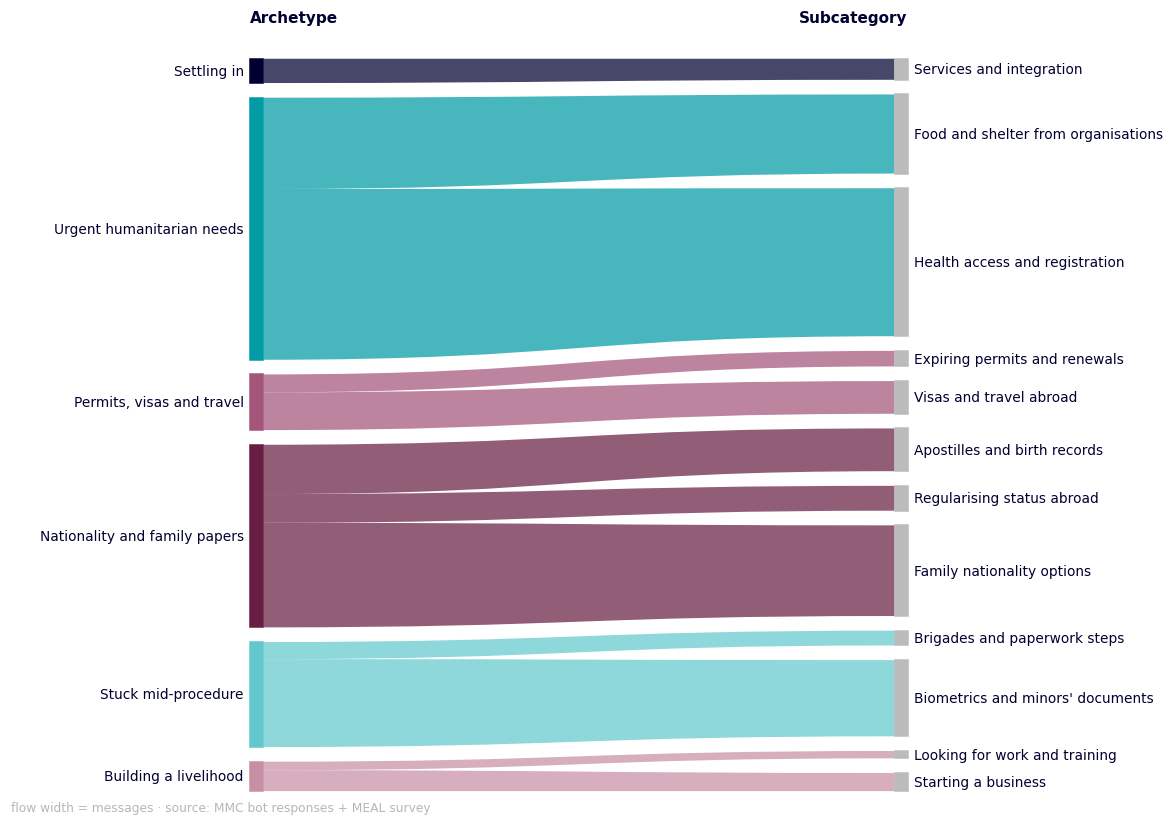

In [11]:
# --- Sankey: the two-level taxonomy, archetype to subcategory ---
from sami import viz

_sub_dim = pd.read_csv(_src.parent / "exports" / "dim_subcluster.csv")
_clu_dim = pd.read_csv(_src.parent / "exports" / "dim_cluster.csv")

# subcluster_id -10 is the "no conversation text" sentinel: its count columns
# are empty (not zero), so casting to int before dropping it raises, and left
# in it would render as a thirteenth, phantom node.
_sub_dim = _sub_dim[_sub_dim["subcluster_id"] >= 0].copy()
_sub_dim["n_messages"] = _sub_dim["n_messages"].astype(int)

# Sorted by source (the parent) first, for the grouped, low-crossing layout --
# sankey_two_level orders each column by first appearance in the rows.
_links = (_sub_dim.merge(_clu_dim[["cluster_id", "name"]], on="cluster_id")
                  .sort_values("cluster_id")
                  .rename(columns={"name": "source", "subcluster_name": "target",
                                    "n_messages": "value"})
                  [["source", "target", "value"]])
_colors = dict(zip(_clu_dim["name"], _clu_dim["color_hex"]))

fig, ax = plt.subplots(figsize=(11, 7.5))
viz.sankey_two_level(_links, color_map=_colors, ax=ax,
                     left_label="Archetype", right_label="Subcategory")
fig.text(0.012, 0.01, f"flow width = messages · {SRC}",
         ha="left", va="bottom", fontsize=8, color=theme.MUTED)
fig.tight_layout()
plt.show()

## 2d · Reading the messages themselves

The table below is a **redacted sample** — up to a handful of messages drawn from
each subcategory and tone, not a census of the corpus. Person names are removed
from every message shown; the redaction is applied before export, not at display
time. Each subcategory and tone contributes up to a handful of messages here; the
counts and shares elsewhere in this notebook come from the full corpus.

In [12]:
# --- Example messages: a redacted, tone-tagged slice ---
sample = pd.read_csv(_src.parent / "exports" / "fact_message_sample.csv")
assert qa.pii_scan(sample[["text_redacted"]]) == [], "PII in a rendered example"
# filter_examples also takes cluster= and subcluster=, and the filters compose --
# e.g. filter_examples(sample, cluster=4, tone="positive", n=6)
viz.style_examples(viz.filter_examples(sample, tone="negative", n=12))

sentiment_label,subcluster_name,city_canon,text_redacted
negative,Starting a business,Cúcuta,Quiero ayuda para mi emprendimiento ya que por mi edad es difícil conseguir trabajo
negative,Starting a business,Other,"Quisiera saber en q puede ayudarme está entidad, ya q me encuentro desempleada, hace 15 días."
negative,Starting a business,Cúcuta,Como hago para optar por un emprendimiento ya que no cuento con los recursos económicos
negative,Looking for work and training,Medellín,Por estar sin empleo y a mí edad ya no me contratan . Que ayuda podría yo a obtar en este momento ya que tengo un hijo con discapacidad y se me dificulta un trabajo en empresa
negative,Biometrics and minors' documents,Cúcuta,"Necesito esa ayuda ,para acceder a la salud. Ustedes no cuentan con ayuda de trabajo"
negative,Biometrics and minors' documents,Cúcuta,No me a salido mi PPT y lo necesito para trabajar ya que tengo 5 hijos menos de esa soy padre soltero
negative,Biometrics and minors' documents,Bogotá,"Y que requisito píden para sacar ese [nombre],tutor disculpe es que necesito orientarme y a donde me dirijo ? Disculpe"
negative,Biometrics and minors' documents,Soacha,También tengo problema con la eps sacaron ami niño de la eps que debo hacer
negative,Biometrics and minors' documents,Cúcuta,Ninguno de mis hijos son colombianos ellos son venezolanos y necesito sacarle los papeles
negative,Biometrics and minors' documents,Other,yo me e metido en esa página y me dice que no se encuentra nada


## 3 · Needs the archetypes don't separate out

The archetypes above are broad positions, not a fine-grained need list. Some needs are
real and recurring in users' own words but too small, or too entangled with a larger
cluster, to show up as their own group. The probes below count how many messages carry
candidate-need vocabulary, independent of which archetype a user falls into.

> **Directional only.** These probes are keyword patterns, not a validated classifier.
> Recall is unknown, so each count is a **floor** — "at least this many" — and never a
> rate. This is the honest ceiling on what can be claimed without the LLM classification
> step that is out of scope for this pass.


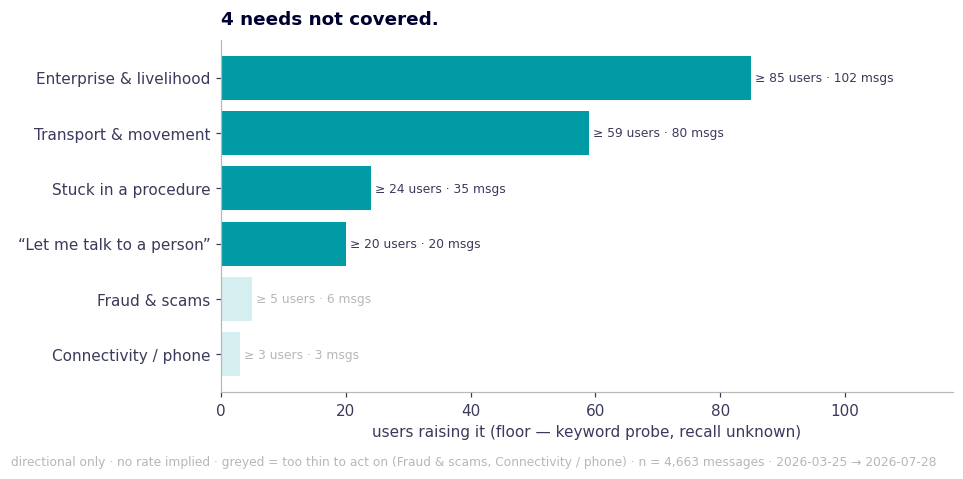

,need,messages,users
0,Enterprise & livelihood,102,85
1,Transport & movement,80,59
2,Stuck in a procedure,35,24
3,“Let me talk to a person”,20,20
4,Fraud & scams,6,5
5,Connectivity / phone,3,3


In [13]:
# --- Figure 3: candidate missing needs ---
probe_rows = []
for slug, pat in taxonomy.CANDIDATE_INTENT_PROBES.items():
    hit = SD.messages["message"].str.contains(pat, case=False, regex=True, na=False)
    probe_rows.append({"need": slug, "messages": int(hit.sum()),
                       "users": int(SD.messages.loc[hit, "user_id"].nunique())})
probes = pd.DataFrame(probe_rows).sort_values("users", ascending=False).reset_index(drop=True)

PROBE_EN = {"transport_logistics": "Transport & movement", "entrepreneurship": "Enterprise & livelihood",
            "procedure_troubleshooting": "Stuck in a procedure", "human_handoff": "“Let me talk to a person”",
            "fraud_protection": "Fraud & scams", "connectivity": "Connectivity / phone"}
# A need raised by fewer than 10 users is not actionable — shown, but visually demoted
# so the eye is not drawn to a signal too thin to plan against.
MATERIAL = 10
fig, ax = plt.subplots(figsize=(8.8, 4.2))
lbl = [PROBE_EN[s] for s in probes["need"]][::-1]
val = probes["users"].values[::-1]
cols = [theme.PRIMARY if v >= MATERIAL else theme.HONGO for v in val]
ax.barh(lbl, val, color=cols)
for y, (u, m) in enumerate(zip(val, probes["messages"].values[::-1])):
    ax.text(u + 0.6, y, f"≥ {u} user{'s' if u != 1 else ''} · {m} msg{'s' if m != 1 else ''}", va="center", fontsize=8,
            color=theme.INK2 if u >= MATERIAL else theme.MUTED)
ax.set_xlabel("users raising it (floor — keyword probe, recall unknown)")
ax.set_xlim(0, val.max() * 1.38)
n_material = int((probes["users"] >= MATERIAL).sum())
ax.set_title(f"{n_material} needs not covered.")
thin = ", ".join(PROBE_EN[s] for s in probes.loc[probes.users < MATERIAL, "need"])
fig.text(0.01, -0.02, f"directional only · no rate implied · greyed = too thin to act on "
                      f"({thin}) · n = {len(SD.messages):,} messages · {WINDOW}",
         fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()
probes.assign(need=lambda d: d["need"].map(PROBE_EN))

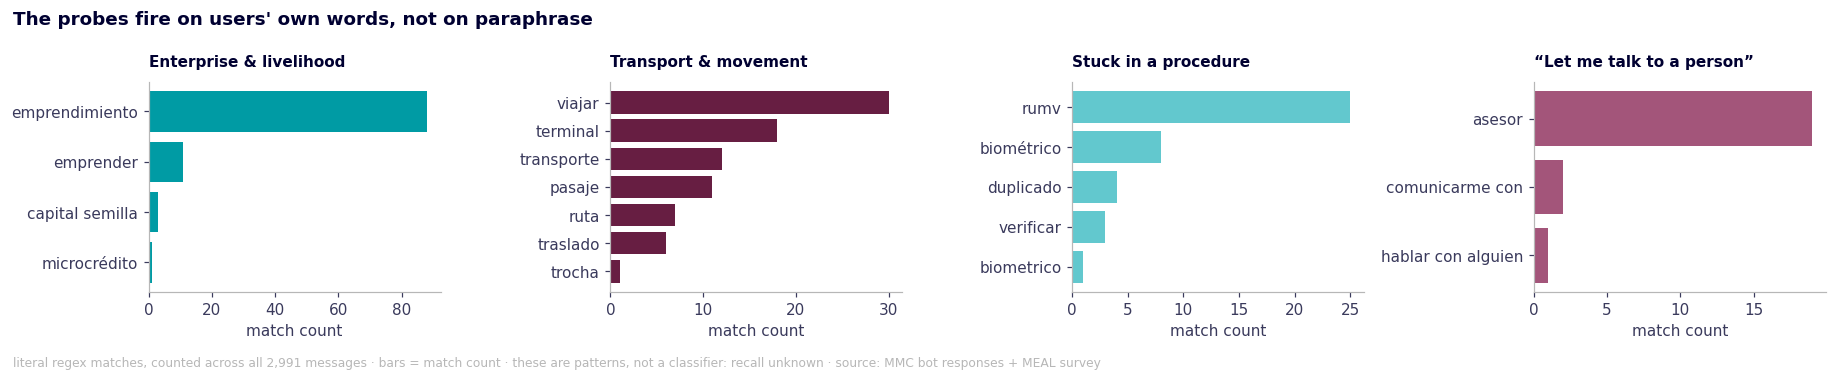

In [14]:
# --- Figure 3b: the words behind the floors ---
# Every term here is a literal regex hit in a user's message. This shows the raw
# evidence the bars above are counted from, so the reader can judge whether each
# pattern is catching the need or catching noise.
from collections import Counter
import re as _re

_material = probes[probes["users"] >= MATERIAL]["need"].tolist()
fig, axes = plt.subplots(1, len(_material), figsize=(4.2 * len(_material), 3.2))

for ax, slug, col in zip(np.atleast_1d(axes), _material, theme.cat_colors(len(_material))):
    pat = taxonomy.CANDIDATE_INTENT_PROBES[slug]
    hits = Counter(
        m.group(0).lower().strip()
        for t in SD.messages["message"].astype(str)
        for m in _re.finditer(pat, t, flags=_re.IGNORECASE)
    )
    top = pd.Series(hits).sort_values(ascending=True).tail(10)
    ax.barh(top.index, top.values, color=col)
    ax.set_title(PROBE_EN[slug], fontsize=10)
    ax.set_xlabel("match count")
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)

fig.suptitle("The probes fire on users' own words, not on paraphrase",
             x=0.01, ha="left", fontsize=12, weight="semibold")
fig.text(0.01, -0.03, "literal regex matches, counted across all 2,991 messages · bars = match count "
                      f"· these are patterns, not a classifier: recall unknown · {SRC}",
         fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()


**So what.** *Transport & movement* and *Enterprise & livelihood* are large enough to
deserve their own intents, but no archetype separates them out — they surface as
vocabulary inside broader clusters, not as a group planning can see on its own.
*"Let me talk to a person"* is a **routing request the bot cannot honour**, not a topic —
it returns in the MEAL free text in §5. And the negative results are findings too:
**connectivity/phone support is effectively absent (one message in 2,991)** and should not
enter the intent roadmap.


## 4 · Tone — validated first, used second

A sentiment model is only worth as much as its agreement with a human reading of the same
messages. The protocol: draw 200 messages stratified by cluster_id × predicted sentiment, **emit
them without the prediction**, label them blind, then compare. Labelling that can see the
model's answer measures anchoring, not agreement.


In [15]:
sent = nlp.sentiment_messages(SD.messages)

# NOTE: validation/tone_sample_200.csv is deliberately NOT read here. It is the
# blind sample as drawn, still keyed on the pre-migration row number, so joining
# anything to it silently yields NaN. It is kept only as the audit trail of what
# was sent to the labeller; message text comes from the spine below.
analyst = pd.read_csv("../validation/tone_labels_analyst.csv", encoding="utf-8")
reviewer_path = pathlib.Path("../validation/tone_labels_reviewer.csv")
if reviewer_path.exists():
    human = pd.read_csv(reviewer_path, encoding="utf-8")["label_reviewer"]
    LABELLER = "analyst + reviewer"
else:
    human = analyst["label_analyst"]
    LABELLER = "analyst pass only (no reviewer file present)"

# Matched on message_id, never by position. `sent` is aligned positionally to
# the spine, so the old `sent.loc[analyst["message_id"]]` silently compared the
# analyst's judgement of one message against the model's judgement of another
# once message_id stopped being a row number. align_gold raises instead.
model_labels = validation.align_gold(analyst["message_id"], SD.messages, sent)
report = validation.validation_report(human, model_labels)
GATE = report["gate_passed"]
print(f"n = {report['n']} · labelled by: {LABELLER}")
print(f"Cohen's κ = {report['kappa']:.3f} · accuracy = {report['accuracy']:.1%} · "
      f"gate (κ ≥ {validation.KAPPA_GATE}) = {'PASS' if GATE else 'FAIL'}")
if not GATE:
    print("→ percentages SUPPRESSED for the rest of this notebook; tone reported as ordering only.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

n = 178 · labelled by: analyst pass only (no reviewer file present)
Cohen's κ = 0.595 · accuracy = 88.2% · gate (κ ≥ 0.7) = FAIL
→ percentages SUPPRESSED for the rest of this notebook; tone reported as ordering only.


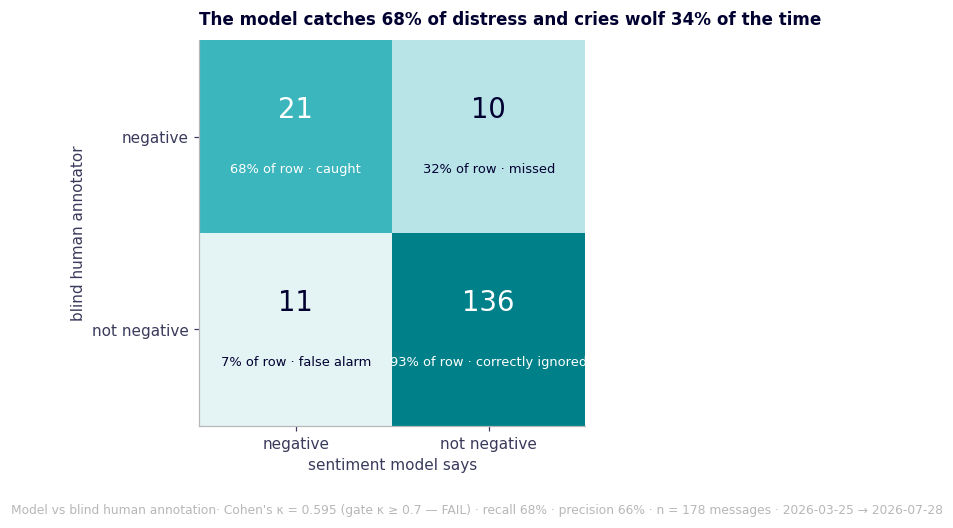

In [16]:
# --- Figure 4: the sentiment model vs a blind HUMAN annotation of the same messages ---
# The reference labels are human, produced without ever seeing the model's answer;
# no LLM is in the labelling loop. Row-normalised because 79% of the sample is one
# cell ("correctly ignored") which would otherwise eat the whole colour scale.
# Raw counts stay printed, so nothing is hidden by the normalisation.
cm = report["confusion"]
cm_pct = cm.div(cm.sum(axis=1), axis=0)
tp = cm.loc["negative", "negative"]; fn = cm.loc["negative", "not_negative"]
fp = cm.loc["not_negative", "negative"]
recall = tp / (tp + fn); precision = tp / (tp + fp)
MEANING = [["caught", "missed"], ["false alarm", "correctly ignored"]]

fig, ax = plt.subplots(figsize=(6.8, 4.5))
ax.imshow(cm_pct.values, cmap=theme.blue_cmap(), vmin=0, vmax=1)
ax.set_xticks([0, 1], ["negative", "not negative"])
ax.set_yticks([0, 1], ["negative", "not negative"])
ax.set_xlabel("sentiment model says"); ax.set_ylabel("blind human annotator")
for i in range(2):
    for j in range(2):
        n, p = cm.values[i, j], cm_pct.values[i, j]
        ink = "white" if p > 0.55 else theme.INK
        ax.text(j, i - 0.14, f"{n}", ha="center", va="center", fontsize=18, color=ink)
        ax.text(j, i + 0.17, f"{p:.0%} of row · {MEANING[i][j]}", ha="center", va="center",
                fontsize=8.5, color=ink)
ax.set_title(f"The model catches {recall:.0%} of distress and cries wolf {1-precision:.0%} of the time",
             fontsize=11)
fig.text(0.01, -0.05,
         f"Model vs blind human annotation· "
         f"Cohen's κ = {report['kappa']:.3f} (gate κ ≥ {validation.KAPPA_GATE} — "
         f"{'PASS' if GATE else 'FAIL'}) · recall {recall:.0%} · precision {precision:.0%} · "
         f"n = {report['n']} messages · {WINDOW}",
         fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()


In [17]:
# Export the human annotation used above as a portable gold-label table. When the
# reviewed gold CSVs arrive they drop straight into this schema (human_label is the
# column they replace); nothing here comes from an LLM.
# Message text is taken from the SPINE, not from tone_sample_200.csv: that sample
# file is still keyed on the pre-migration row number, so a reindex against it
# returns silent NaN. The spine is the only source of truth for message_id -> text.
_spine_text = pd.Series(
    SD.messages["message"].values,
    index=[export.message_key(u, s, m) for u, s, m in
           zip(SD.messages["user_id"], SD.messages["seq"], SD.messages["message"])])
gold = pd.DataFrame({"message_id": analyst["message_id"].values})
gold["message"] = _spine_text.reindex(gold["message_id"]).values
assert gold["message"].notna().all(), "a gold message_id has no text in the spine"
gold["human_label"] = validation.binarize(human).values
gold["model_label"] = validation.binarize(model_labels).values
gold["labelled_by"] = LABELLER
gold_path = pathlib.Path("../validation/tone_gold_labels.csv")
gold.to_csv(gold_path, index=False, encoding="utf-8")
print(f"exported {len(gold)} human annotations → {gold_path}")
gold.head()


exported 178 human annotations → ..\validation\tone_gold_labels.csv

,message_id,message,human_label,model_label,labelled_by
0,8a6eb39d7bf4b861,Me encuentro en Rionegro medellín Antioquia,not_negative,not_negative,analyst pass only (no reviewer file present)
1,7fa1e3cbc6cf8ccc,Yo no tengo pasaporte con el único documento q...,not_negative,not_negative,analyst pass only (no reviewer file present)
2,1570b39cecd19e61,Bogotá Soacha,not_negative,not_negative,analyst pass only (no reviewer file present)
3,be61b601468c0811,English please,not_negative,not_negative,analyst pass only (no reviewer file present)
4,110b02aed6d94301,Y como hago para saber l certificado del ppt e...,not_negative,not_negative,analyst pass only (no reviewer file present)


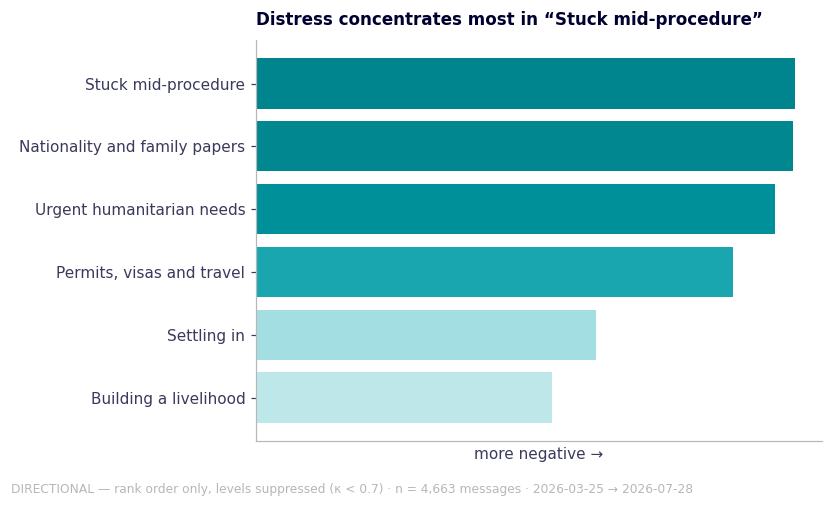

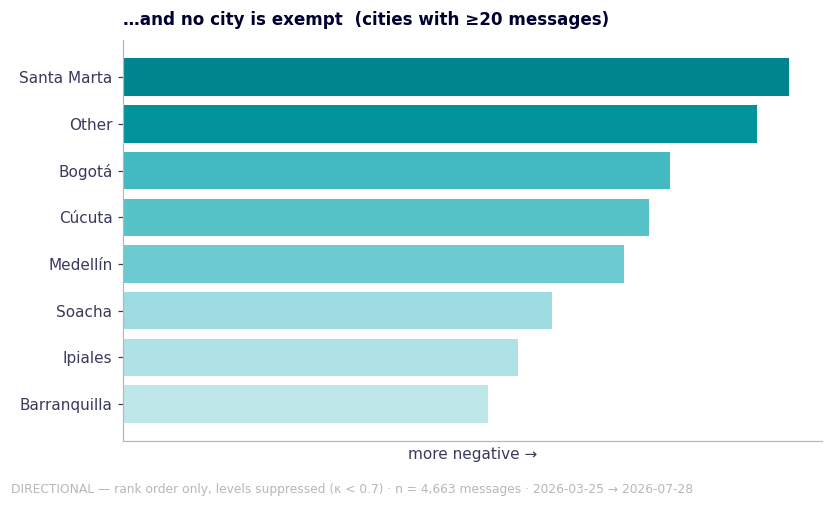

In [18]:
# --- Figures 5 & 6: where negative tone concentrates, one chart each ---
# (ordering only unless the validation gate passed). Bars are shaded by a teal
# gradient on the same quantity they encode — darker = more negative.
neg_arch = metrics.negative_by_cluster(msgs_lab, sent, col="archetype")
city_n = SD.messages["city_canon"].value_counts()
top_cities = city_n[city_n >= 20].head(8).index
mc = SD.messages[SD.messages["city_canon"].isin(top_cities)]
neg_city = (sent.loc[mc.index, "label"] == "negative").groupby(mc["city_canon"]).mean().sort_values(ascending=False)
neg_city.index = [("Other" if c == "Otra" else c) for c in neg_city.index]

def _neg_bars(s, title, lbls):
    fig, ax = plt.subplots(figsize=(7.6, 4.4))
    cmap = theme.blue_cmap(); norm = plt.Normalize(float(s.values.min()), float(s.values.max()))
    colors = [cmap(0.30 + 0.60 * norm(v)) for v in s.values]
    ax.barh(lbls[::-1], s.values[::-1], color=colors[::-1])
    ax.set_title(title, fontsize=11)
    if GATE:
        for y, v in enumerate(s.values[::-1]):
            ax.text(v + 0.004, y, f"{v:.0%}", va="center", fontsize=8, color=theme.INK2)
        ax.set_xlabel("% of messages classified negative")
    else:
        ax.set_xticks([]); ax.set_xlabel("more negative →")
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    banner = "" if GATE else f"DIRECTIONAL — rank order only, levels suppressed (κ < {validation.KAPPA_GATE}) · "
    fig.text(0.01, -0.03, f"{banner}n = {len(SD.messages):,} messages · {WINDOW}", fontsize=8, color=theme.MUTED)
    plt.tight_layout(); plt.show()

_top_arch_name = NAMES[neg_arch.index[0]]
_neg_bars(neg_arch, f"Distress concentrates most in \u201c{_top_arch_name}\u201d",
          [NAMES.get(i, str(i)) for i in neg_arch.index])
_neg_bars(neg_city, "…and no city is exempt  (cities with ≥20 messages)",
          list(neg_city.index))


In [19]:
# # --- Figure 6b: what distress sounds like ---
# # A vocabulary picture, not a rate: it quotes no percentage, so it is unaffected by
# # the suppressed κ gate. Documents are pooled per user per tone class, so the
# # min_user_df floor in ctfidf_terms remains a distinct-user floor and still does
# # its PII job (a user contributing to both classes is counted once per class).
# _mt = SD.messages.assign(_neg=(sent["label"] == "negative").values)
# tone_docs = (_mt.groupby(["user_id", "_neg"])["message"]
#                 .apply(lambda s: " ".join(s.astype(str))).reset_index())
# tone_terms = clusters.ctfidf_terms(tone_docs["message"].tolist(),
#                                    tone_docs["_neg"].astype(int).values, top_n=40)
# assert qa.pii_scan(pd.DataFrame({"term": sorted(set(tone_terms[0].index) | set(tone_terms[1].index))})) == []

# fig, axes = plt.subplots(1, 2, figsize=(11.2, 3.7))
# for ax, (k, name, col) in zip(axes, [(1, "Messages the model reads as negative", theme.ACCENT),
#                                      (0, "Everything else", theme.PRIMARY)]):
#     ax.imshow(theme.wordcloud_image(tone_terms[k], col, width=560, height=300),
#               interpolation="bilinear")
#     ax.set_title(name, fontsize=10)
#     ax.axis("off")
# fig.suptitle("Distress carries its own vocabulary", x=0.01, ha="left",
#              fontsize=12, weight="semibold")
# fig.text(0.01, -0.04, "c-TF-IDF over per-user documents split by model tone label · word size and "
#                       f"tint = distinctiveness · no rate is quoted, so the κ gate does not bind "
#                       f"this figure · {SRC}", fontsize=8, color=theme.MUTED)
# plt.tight_layout(); plt.show()


**So what.** The ordering survives the validation gate: distress sits where stakes are
highest and the bot resolves least — protection and journey questions — while employment
is calmest. Because tone is spread across cities rather than concentrated, this is a
**content-and-escalation problem, not a location problem**.


## 5 · Voices

Six MEAL responses, verbatim in Spanish, grouped by what they ask MMC to change. These are
testimony, not data points — the free-text box is the only place users tell the programme
what to do differently.

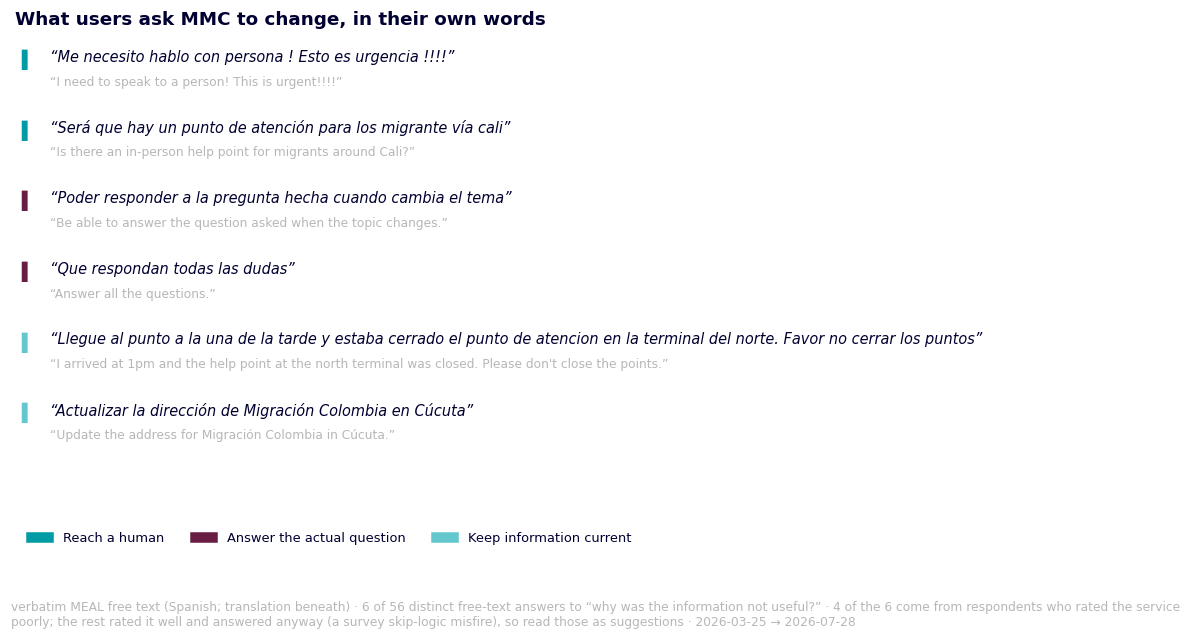

In [20]:
# --- Figure 7: the voices panel ---
from matplotlib.patches import Patch

# These six are curated (theme grouping and translation are editorial), but they
# are NOT free-floating: every one is checked against the live export below, so a
# refresh that drops a quote fails here instead of shipping a verbatim nobody can
# trace. They come from the MEAL "¿Por qué la información entregada no fue útil?"
# free text -- `no_usefulness_reason`, not `recommendation_text`, which the v2
# survey never populated.
VOICES = [
    ("Reach a human", "Me necesito hablo con persona ! Esto es urgencia !!!!",
     "“I need to speak to a person! This is urgent!!!!”"),
    ("Reach a human", "Será que hay un punto de atención para los migrante vía cali",
     "“Is there an in-person help point for migrants around Cali?”"),
    ("Answer the actual question", "Poder responder a la pregunta hecha cuando cambia el tema",
     "“Be able to answer the question asked when the topic changes.”"),
    ("Answer the actual question", "Que respondan todas las dudas",
     "“Answer all the questions.”"),
    ("Keep information current", "Llegue al punto a la una de la tarde y estaba cerrado el punto de atencion en la terminal del norte. Favor no cerrar los puntos",
     "“I arrived at 1pm and the help point at the north terminal was closed. Please don't close the points.”"),
    ("Keep information current", "Actualizar la dirección de Migración Colombia en Cúcuta",
     "“Update the address for Migración Colombia in Cúcuta.”"),
]
assert qa.pii_scan(pd.DataFrame({"q": [v[1] for v in VOICES]})) == [], "PII in a quote"

_meal = export.build_fact_meal(SD.meal)
_reason = _meal["no_usefulness_reason"].dropna().astype(str).str.strip()
_pool = set(_reason)
_valid_pool = set(_meal.loc[_meal["reason_is_valid"], "no_usefulness_reason"]
                  .dropna().astype(str).str.strip())
_missing = [es for _, es, _ in VOICES if es not in _pool]
assert not _missing, (
    f"{len(_missing)} quoted verbatim(s) are no longer in the export and cannot be "
    f"traced to a respondent: {_missing[:2]}. Re-pick them from "
    "`no_usefulness_reason` rather than shipping an unverifiable quote.")

# How many of the six sit inside the `reason_is_valid` subset. The rest come from
# respondents who rated the service Útil/Muy útil -- the v2 skip-logic misfire
# documented in export.REASON_VALID_RATINGS -- so their text is a suggestion, not
# a stated reason the answer failed. Both are legitimate here; the caption says so
# rather than letting the reader assume all six are complaints.
_n_valid_quoted = sum(1 for _, es, _ in VOICES if es in _valid_pool)

themes = list(dict.fromkeys(v[0] for v in VOICES))
THEME_COLOR = {t: c for t, c in zip(themes, theme.cat_colors(len(themes)))}
fig, ax = plt.subplots(figsize=(11, 5.2))
ax.axis("off")
y = 0.98
for t, es, en in VOICES:
    ax.text(0.005, y, "▍", transform=ax.transAxes, fontsize=13, color=THEME_COLOR[t], va="top")
    ax.text(0.03, y, f"“{es}”", transform=ax.transAxes, fontsize=9.5, color=theme.INK, va="top", style="italic")
    ax.text(0.03, y - 0.055, en, transform=ax.transAxes, fontsize=8, color=theme.MUTED, va="top")
    y -= 0.15
ax.set_title("What users ask MMC to change, in their own words", loc="left", fontsize=12, weight="semibold")
# Theme key as a single legend rather than a label repeated on every quote.
ax.legend(handles=[Patch(color=THEME_COLOR[t], label=t) for t in themes],
          loc="upper left", bbox_to_anchor=(0, -0.02), ncol=len(themes), fontsize=8.5, frameon=False)
fig.text(0.01, -0.10,
         f"verbatim MEAL free text (Spanish; translation beneath) · "
         f"{len(VOICES)} of {len(_pool)} distinct free-text answers to “why was the "
         f"information not useful?” · {_n_valid_quoted} of the {len(VOICES)} come from "
         f"respondents who rated the service poorly; the rest rated it well and answered "
         f"anyway (a survey skip-logic misfire), so read those as suggestions · {WINDOW}",
         fontsize=8, color=theme.MUTED, wrap=True)
plt.tight_layout(); plt.show()

## What we now know

1. **The archetypes are stable under resampling, and they are now the pipeline's
   categorization.** k was chosen on stability, not on a flat silhouette curve; the
   chosen-k solution holds at mean pairwise ARI ≈ 0.84 across 50 resamples — well clear
   of the 0.6 bar. That is a statement about *reproducibility*, not about the segments
   being the only true reading of the corpus. They differ by *position relative to the
   system* — urgent need now, nationality for a child, stuck mid-procedure, permits and
   travel, settling in, building a livelihood. **This replaces the four-archetype reading
   of the previous corpus** (the larger v2 corpus splits documentation into
   child-nationality versus adult-permits, and splits humanitarian need into acute versus
   settlement) **and it replaces the platform's own `Chat_summary` labelling**, which was
   retired outright as its coverage degraded under the v2 platform's free-text prose.
2. **Five of the six archetypes divide again, and the children are the more
   stable level.** Twelve subcategories clear a 30-user floor, and their mean
   split stability (ARI 0.841) edges the parent pass's 0.836 — the opposite of
   what subdividing was expected to do. *Settling in* did not split and keeps
   one child covering the whole parent, so the drill-down stays total. The
   children are substantive: *Nationality and family papers* separates onward
   migration to Spain from apostilles and birth records from general family
   options — three different problems one label had flattened into one.
3. **Two needs deserve their own intents.** Transport & movement and enterprise &
   livelihood are each raised by ~50 users in their own words, but no archetype
   separates them out — they surface inside broader clusters where they cannot be
   planned for.
4. **"Let me talk to a person" is a routing gap, not a topic.** It is small on both
   counts — the probe reaches 20 users in the message corpus, and one of the handful of
   MEAL free-text answers asks for it directly — but it is a *different kind* of request
   from the rest: no amount of better content answers it. Both figures are floors from
   unvalidated probes and a 100-odd-response survey, so treat the size as unknown and
   the kind as the finding.
5. **Connectivity support is not a need in this corpus** — a hypothesis ruled out, which
   should stop it entering the roadmap.
6. **The tone signal is usable for ordering, not for rates.** Blind validation kept the
   model below the 0.7 bar, so no negative-share percentage is quoted anywhere in this
   notebook. Distress concentrates in some archetypes more than others and is spread
   across cities.

**The binding constraint on this notebook is measurement, not method.** Two findings — the
size of the tone problem, and the true rate of the missing intents — need a labelled
dataset that does not yet exist. That is a concrete, cheap next step: extend the blind
labelling protocol in `validation/` from 200 messages to a two-human sample.

In [21]:
recon_bottom = SD.reconciliation.copy()
assert recon_bottom.equals(recon_top), "reconciliation drifted between top and bottom"
print("Reconciliation identical to top of notebook ✓")
recon_bottom

Reconciliation identical to top of notebook ✓


,metric,value
0,users,1392
1,records,1459
2,messages,4663
3,users_with_text,1198
4,meal_responses,115
5,meal_response_rate_pct,8.3
6,repeat_askers_pct,10.6
7,negative_tone_pct,pending


---
## Annex — supporting evidence

Material that supports the main line but does not belong in it.

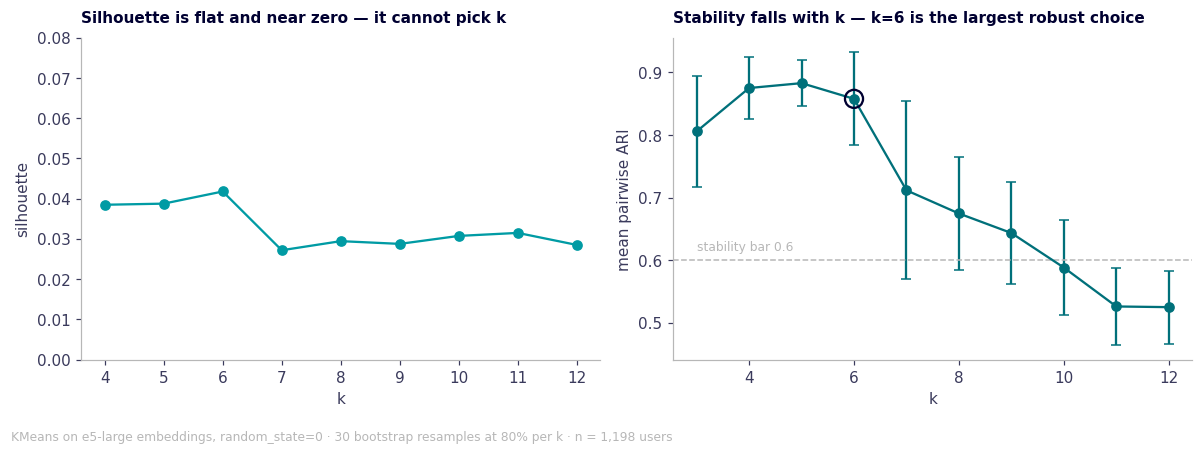

,silhouette,davies_bouldin,mean_ari,std_ari,stable
4,0.038461,3.988986,0.874831,0.049516,True
5,0.038741,3.858557,0.882626,0.036606,True
6,0.041763,3.725863,0.857519,0.074437,True
7,0.027160,3.809572,0.711456,0.142174,True
8,0.029422,3.957208,0.674464,0.090577,True
9,0.028741,3.901096,0.643257,0.081971,True
10,0.030723,3.795641,0.588089,0.076462,False
11,0.031467,3.756103,0.526004,0.061373,False
12,0.028477,4.003314,0.524918,0.058133,False
3,NaN,NaN,0.80554,0.088402,True


In [22]:
# --- A1: the k-selection evidence ---
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
axes[0].plot(scan.index, scan["silhouette"], marker="o", color=theme.PRIMARY)
axes[0].set_title("Silhouette is flat and near zero — it cannot pick k", fontsize=10)
axes[0].set_xlabel("k"); axes[0].set_ylabel("silhouette"); axes[0].set_ylim(0, 0.08)

ks = sorted(stab_curve)
means = [stab_curve[k]["mean_ari"] for k in ks]
sds = [stab_curve[k]["std_ari"] for k in ks]
axes[1].errorbar(ks, means, yerr=sds, marker="o", color=theme.ARBOL, capsize=3)
axes[1].axhline(clusters.STABILITY_BAR, ls="--", lw=1, color=theme.MUTED)
axes[1].text(ks[0], clusters.STABILITY_BAR + 0.015, "stability bar 0.6", ha="left",
             fontsize=8, color=theme.MUTED)
axes[1].scatter([K], [stab_curve[K]["mean_ari"]], s=140, facecolors="none",
                edgecolors=theme.INK, linewidths=1.5, zorder=5)
axes[1].set_title(f"Stability falls with k — k={K} is the largest robust choice", fontsize=10)
axes[1].set_xlabel("k"); axes[1].set_ylabel("mean pairwise ARI")
for ax in axes:
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
fig.text(0.01, -0.04, f"KMeans on e5-large embeddings, random_state={RANDOM_STATE} · "
                      f"30 bootstrap resamples at 80% per k · n = {len(docs):,} users",
         fontsize=8, color=theme.MUTED)
plt.tight_layout(); plt.show()
pd.concat([scan, pd.DataFrame(stab_curve).T[["mean_ari", "std_ari", "stable"]]], axis=1)

In [23]:
# --- A2: what the heaviest askers keep asking about ---
per_user = SD.messages.groupby("user_id").size()
p90 = per_user.quantile(0.90)
heavy = set(per_user[per_user >= p90].index)
# One document per user (not two pooled blobs) so the distinct-user floor in
# ctfidf_terms still applies here — annex term lists are rendered, so they need the
# same PII guard as the main line.
heavy_terms = clusters.ctfidf_terms(
    docs["doc"].tolist(),
    [1 if u in heavy else 0 for u in docs["user_id"]],
    top_n=14)
print(f"repeat askers: {len(heavy)} users (≥ p90 = {p90:.0f} messages), "
      f"{per_user[list(heavy)].sum():,} messages")
pd.DataFrame({"distinctive to repeat askers": heavy_terms[1].index,
              "c-TF-IDF": heavy_terms[1].values.round(4)})

repeat askers: 148 users (≥ p90 = 7 messages), 1,855 messages


,distinctive to repeat askers,c-TF-IDF
0,arreglar,0.0
1,situación,0.0
2,migratoria,0.0
3,salud,0.0
4,niños,0.0
5,dame,0.0
6,pasos,0.0
7,permiso,0.0
8,trabajar,0.0
9,siendo,0.0


> **A3 is model output, not a finding.** The sentiment model is natively
> three-class, but [tone_labels_analyst.csv](../validation/tone_labels_analyst.csv)
> distinguishes only *negative* from *not negative* — there is **no human label
> anywhere in this project that separates neutral from positive**. A three-class κ
> is therefore not computable, and the κ measured on the *easier* binary task is an
> upper bound on what the three-class agreement could be. Nothing below may be
> quoted as a rate or carried into a recommendation.
>
> **The gold labels were re-keyed for the v2 corpus (2026-07-28).** They were
> written when `message_id` was a row number; after the migration to a content
> hash, the old join resolved to unrelated rows and produced a κ from noise. The
> 200 labels were re-matched onto the new ids by message text; **178 survived**
> and 22 were dropped because their text (`Gracias`, `En Bogotá`, …) is not unique
> in the corpus and cannot be attributed to the message the analyst actually read.
> All 31 negatives survived, so the minority class is intact. The κ printed above
> is measured on those 178.


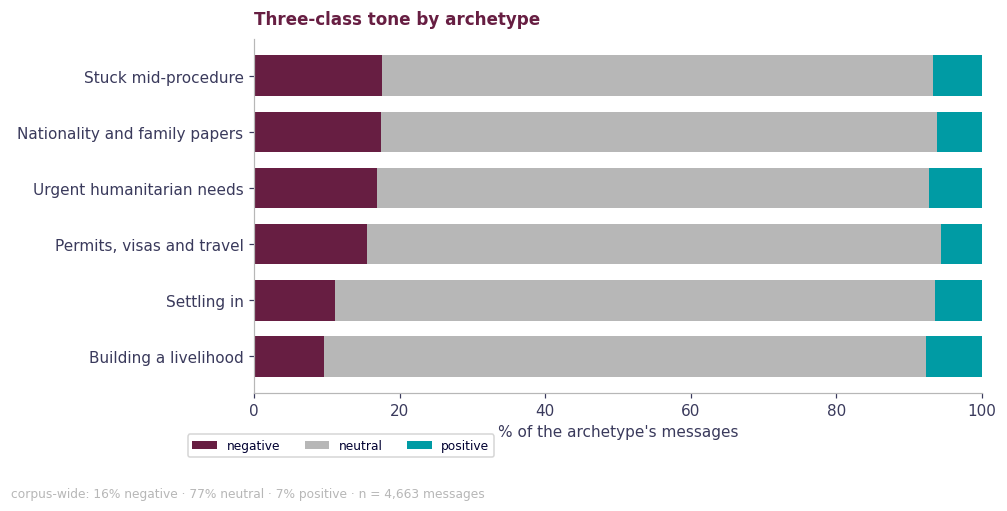

In [24]:
# --- A3: three-class tone distribution — UNVALIDATED, shown as texture only ---
# Polarity encoding: two poles (wine = negative, teal = positive) either side of a
# neutral grey midpoint. Archetypes ordered by negative share so the gradient is
# the reading order.
THREE = list(nlp.SENTIMENT_LABELS)                      # negative, neutral, positive
TONE_COLOR = {"negative": theme.ACCENT, "neutral": theme.MUTED, "positive": theme.PRIMARY}
by_arch = (pd.crosstab(msgs_lab["archetype"], sent.loc[msgs_lab.index, "label"], normalize="index")
             .reindex(columns=THREE).fillna(0))
by_arch = by_arch.sort_values("negative")
overall = sent["label"].value_counts(normalize=True).reindex(THREE).fillna(0)

fig, ax = plt.subplots(figsize=(9.2, 4.4))
left = np.zeros(len(by_arch))
for _tone in THREE:
    vals = by_arch[_tone].values * 100
    ax.barh([NAMES.get(i, str(i)) for i in by_arch.index], vals, left=left,
            color=TONE_COLOR[_tone], label=_tone, height=0.72)
    left += vals
ax.set_xlim(0, 100); ax.set_xlabel("% of the archetype's messages")
ax.legend(fontsize=8, frameon=True, ncol=3, bbox_to_anchor=(-.1, -0.2), loc="lower left")
ax.set_title("Three-class tone by archetype", fontsize=11,
             color=theme.ACCENT)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
fig.text(0.01, -0.04, f"corpus-wide: {overall['negative']:.0%} negative · {overall['neutral']:.0%} "
                      f"neutral · {overall['positive']:.0%} positive · n = {len(SD.messages):,} messages",
         fontsize=8, color=theme.MUTED)

plt.tight_layout(); plt.show()
